In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

root = Path.cwd().parent / "datasets" / "excel"


In [86]:
business_dates = pd.read_excel(root / "business_dates.xlsx", index_col=0)['Values']
sheet_names_str = [key.strftime('%Y-%m-%d') for key in business_dates]
filtered_etfs = pd.read_excel(root / "new_filtered_weights.xlsx", sheet_name=sheet_names_str)


In [87]:
etfs = set()
for date, df in filtered_etfs.items():
    filtered_etf_list = df['Key'][df['Value']==1]
    
    if len(filtered_etf_list) > 0:
        etfs.update(filtered_etf_list)


In [88]:
returns_df = pd.read_csv(root / "new_etf_returns.csv", index_col=0)
# returns_df = pd.read_csv(root / "new_etf_ewma.csv", index_col=0)


In [89]:
sorted_etfs = sorted(etfs)

new_returns = returns_df[['Date'] + sorted_etfs].fillna(method='ffill').drop('Date', axis=1)
# new_returns = returns_df[['Date'] + sorted_etfs].dropna().drop('Date', axis=1)

new_returns


/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_67172/2465611373.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  new_returns = returns_df[['Date'] + sorted_etfs].fillna(method='ffill').drop('Date', axis=1)


,AAAU,AAXJ,ACWI,ACWX,AGG,AGGY,AGZ,AIA,AIQ,AIRR,...,XRT,XSD,XSLV,XSMO,XSOE,XSW,XT,XTN,XYLD,ZROZ
0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.0,0.001927,0.000911,-0.001030,0.000463,0.000000,-0.000088,0.000243,0.000000,-0.000619,...,0.008112,-0.009790,0.012651,0.002546,0.000000,-0.001844,0.003281,0.003333,-0.001851,-0.008166
2,0.0,-0.019633,-0.015239,-0.018726,0.003788,0.004480,0.000972,-0.021406,0.000000,-0.009957,...,-0.021230,-0.026345,-0.005101,-0.014942,-0.036894,-0.015088,-0.016099,-0.021134,-0.013288,0.020334
3,0.0,-0.028272,-0.023588,-0.022837,-0.000092,0.000000,0.000971,-0.022128,0.000000,-0.038896,...,-0.003543,-0.033255,-0.017297,-0.028798,-0.018453,-0.025094,-0.023580,-0.036835,-0.024710,0.000441
4,0.0,-0.008314,-0.011622,-0.010531,0.002211,0.000000,0.001146,-0.009966,0.000000,0.000000,...,-0.030757,-0.016546,-0.015423,-0.017415,-0.020910,0.001067,-0.012433,-0.012161,-0.002891,0.005281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2499,0.0,0.002382,0.001753,0.000893,0.002202,0.003389,0.000987,0.006270,0.002920,-0.000394,...,0.010251,0.000182,0.007033,0.002412,0.001922,0.002258,0.002617,0.002148,0.001474,0.010760
2500,0.0,0.008399,0.001330,0.003562,0.000200,-0.001153,0.001053,0.011291,0.002330,-0.003351,...,-0.000458,-0.006440,-0.001488,-0.001205,0.008579,-0.002300,0.001222,-0.001826,0.000491,-0.006655
2501,0.0,-0.001717,-0.003435,-0.003116,0.001199,0.000906,0.000678,0.004273,-0.001552,-0.007134,...,-0.007710,-0.007311,-0.004143,-0.006857,-0.003581,-0.003458,-0.006247,-0.007922,-0.000245,0.003635
2502,0.0,0.003538,0.000000,0.002227,-0.000399,0.000226,-0.001812,0.004751,-0.001650,-0.009894,...,-0.006839,-0.001659,0.001074,-0.010988,0.002814,-0.006743,-0.000569,-0.003865,0.000000,-0.004394


In [90]:
scaled_returns = StandardScaler().fit_transform(new_returns)

pca = PCA()
pca_result = pca.fit_transform(scaled_returns)
pca_result


array([[-7.11622626e-01, -1.10183148e-01, -6.58921449e-02, ...,
         1.39806187e-03, -2.70388064e-04, -9.90936868e-04],
       [ 1.86375478e+00,  2.60823935e-01, -1.73788988e+00, ...,
         1.03779931e-02, -1.65772521e-02,  2.78798060e-02],
       [-2.11826676e+01,  9.86953614e+00,  6.25295533e+00, ...,
        -1.08264909e-02, -3.84199633e-03, -3.17618898e-02],
       ...,
       [-7.68859138e+00,  8.98958900e-01, -2.40090372e+00, ...,
        -2.34627817e-02,  1.82386963e-02, -2.25472095e-03],
       [-1.94045071e+00,  3.93922398e-01, -2.85579754e+00, ...,
         3.57311553e-03, -1.09366454e-02, -5.27384525e-03],
       [-1.36292441e+01, -3.92822183e+00, -4.96281098e+00, ...,
         2.20198904e-02, -2.39708446e-02,  2.08772490e-02]])

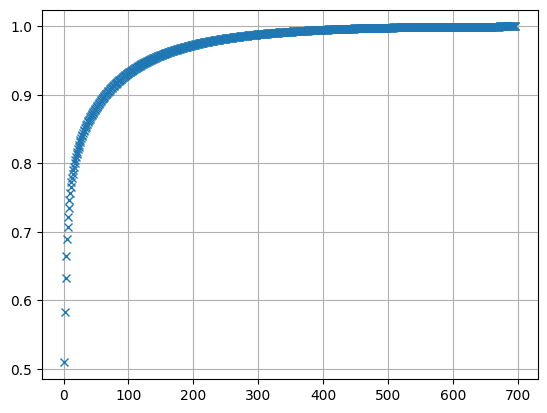

(None, None)

In [91]:
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), 'x')
plt.grid(True), plt.show()


In [92]:
cols = new_returns.columns

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(cols))],
    index=cols
)


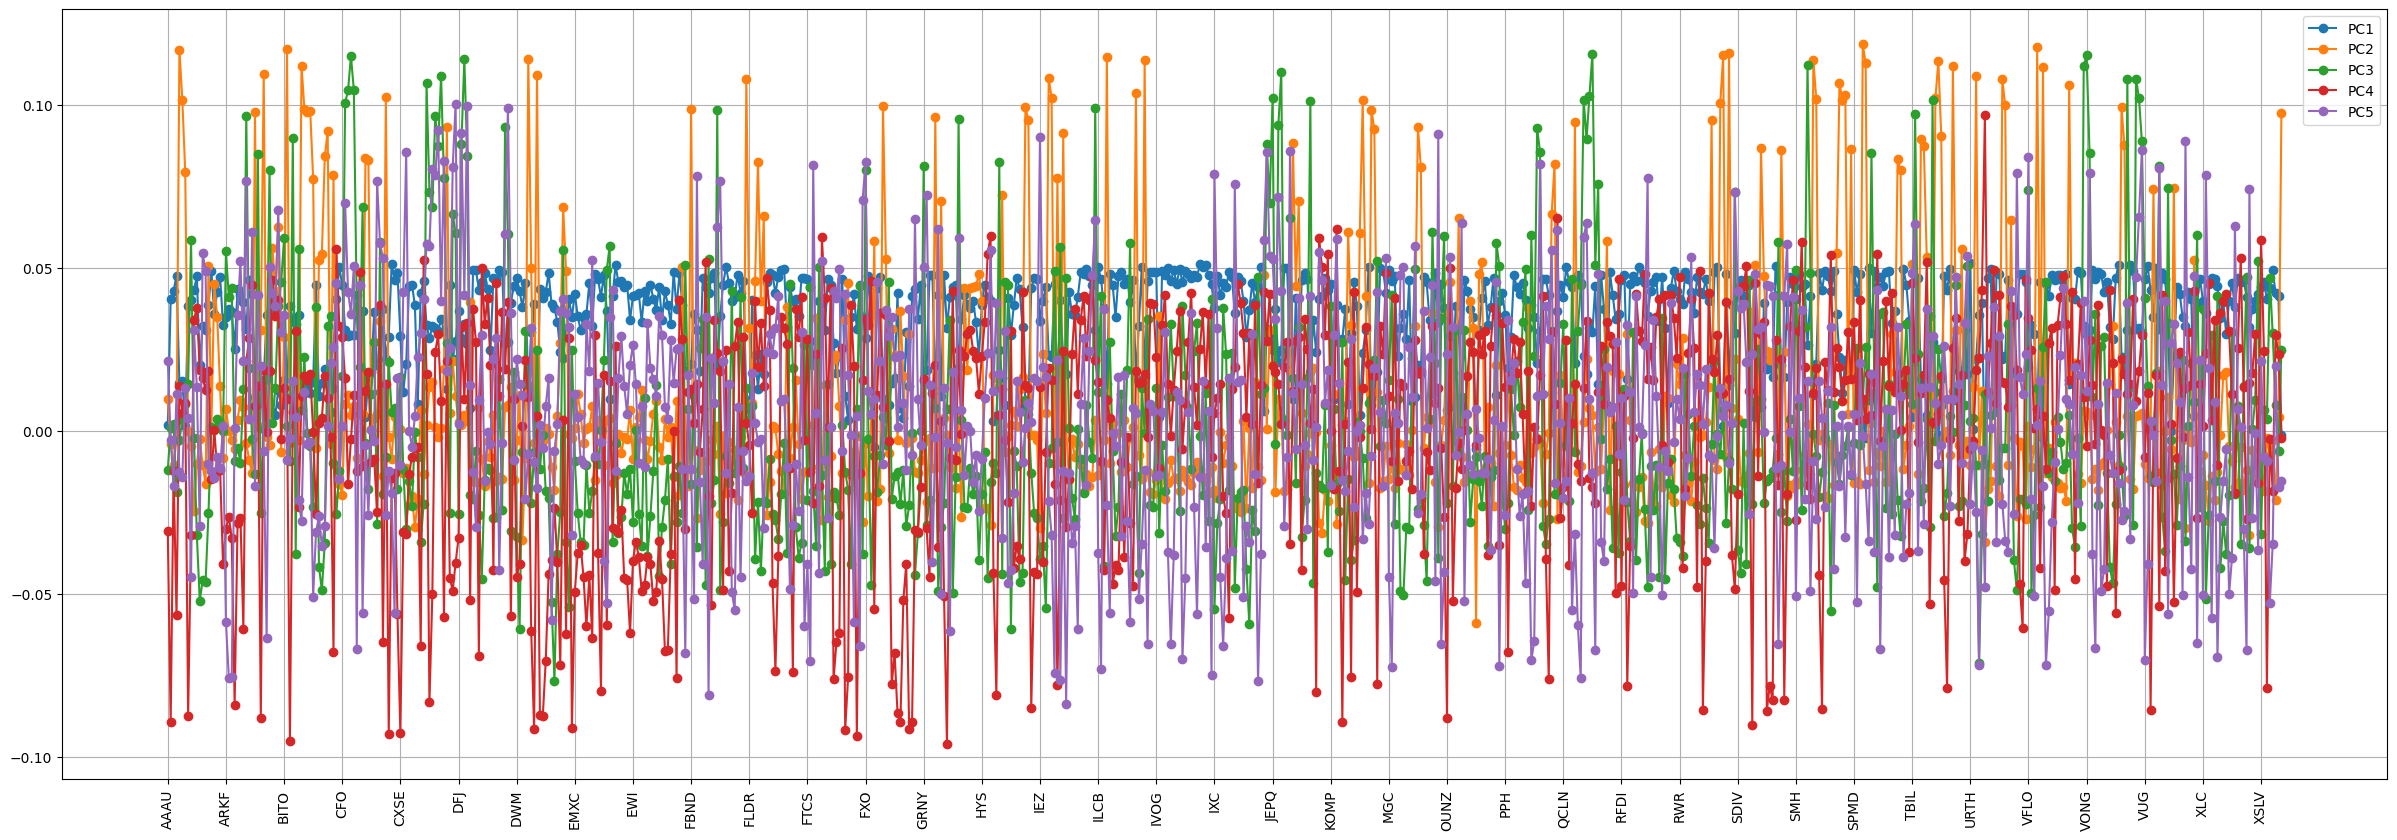

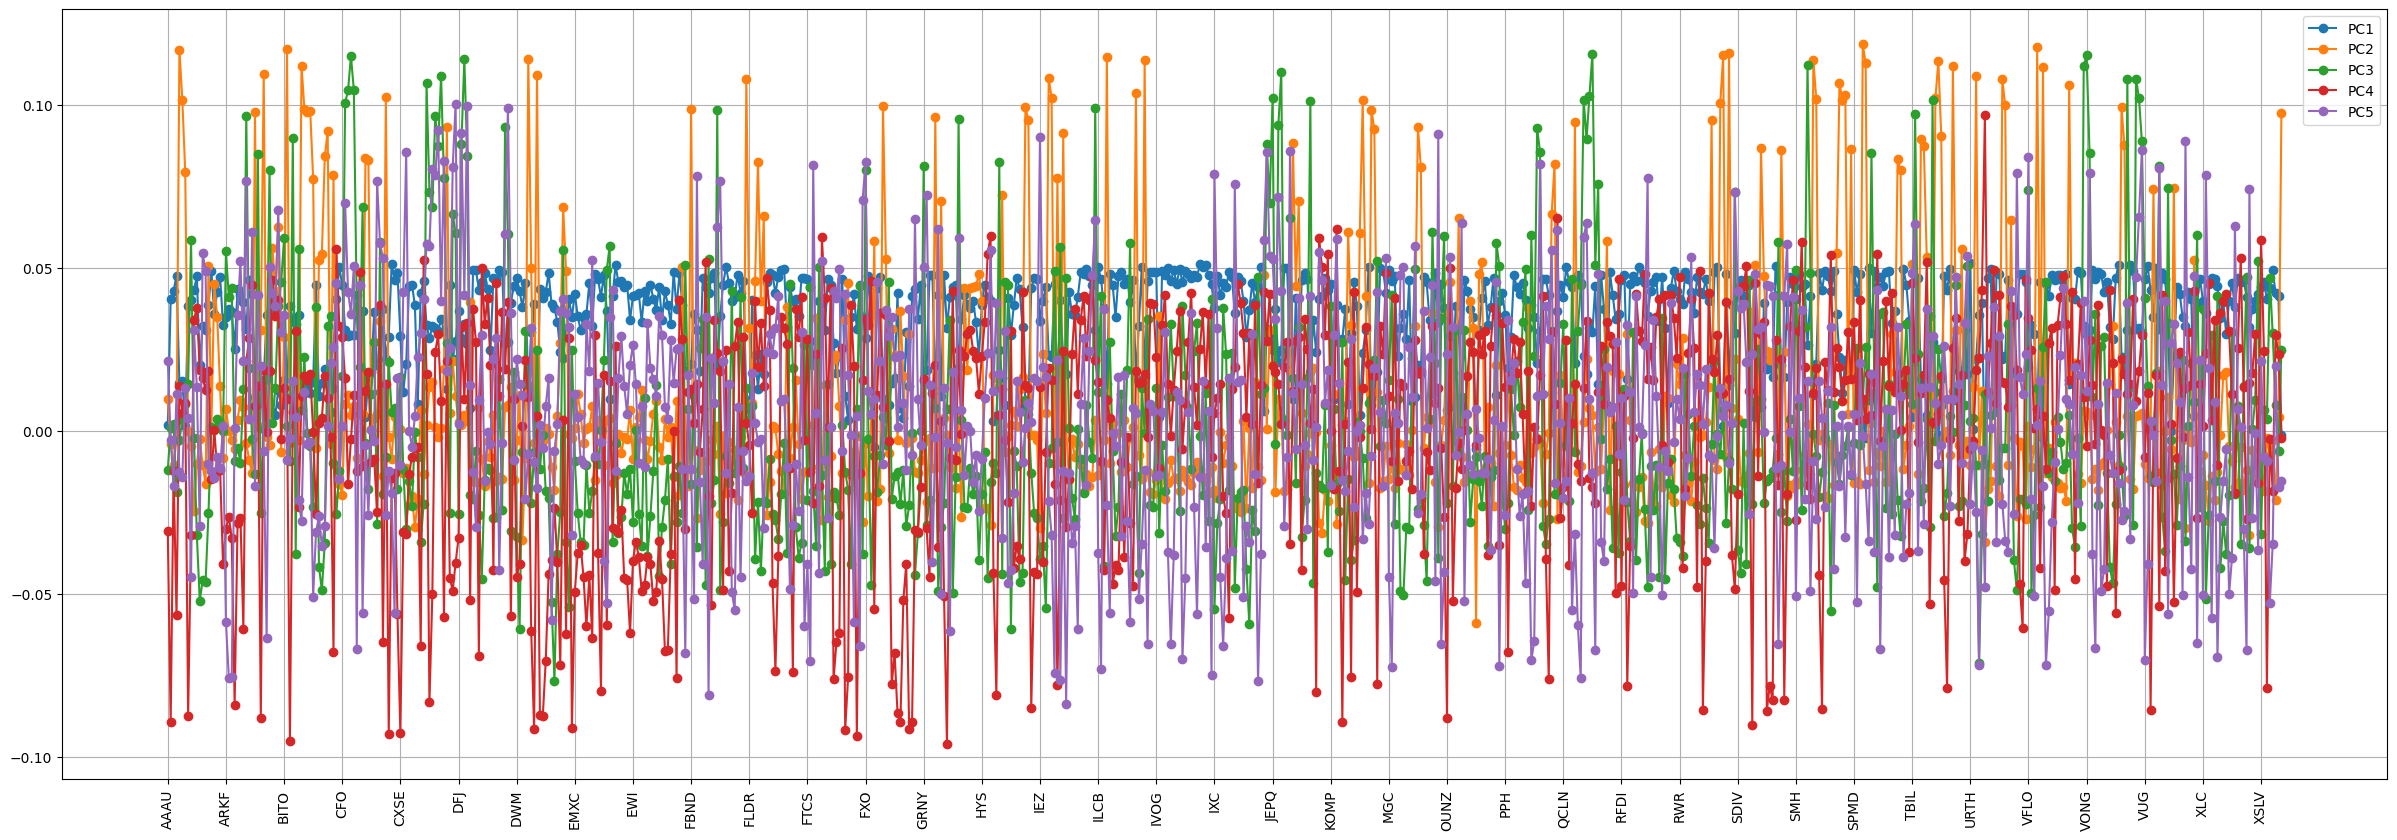

(<matplotlib.legend.Legend at 0x17752a970>, None, None)

In [81]:
pca_values = pca.components_.T

plt.figure(figsize=(30,10))
for i in range(5):
    plt.plot(sorted_etfs, pca_values[:, i], label=f'PC{i+1}', marker='o')
    
plt.xticks(sorted_etfs[::20], rotation=90)
plt.legend(), plt.grid(), plt.show()


plt.figure(figsize=(30,10))
for i in range(5):
    plt.plot(loadings.index, loadings[f'PC{i+1}'], label=f'PC{i+1}', marker='o')

plt.xticks(loadings.index[::20], rotation=90)
plt.legend(), plt.grid(), plt.show()


In [82]:
ind_start = 752 # 2019-01-02
window_size = 250
pca_results = []

initial_returns = returns_df[['Date'] + sorted_etfs].fillna(method='ffill').drop('Date', axis=1)

for i in range(window_size, len(returns_df)):
    new_returns = initial_returns.iloc[i-window_size:i]
    
    pca = PCA()
    scaled_returns = StandardScaler().fit_transform(new_returns)
    pca_result = pca.fit_transform(scaled_returns)
    
    pca_results.append(pca.explained_variance_ratio_[:5])
   
pca_results = np.array(pca_results) 
pca_results


/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_67172/3425135982.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  initial_returns = returns_df[['Date'] + sorted_etfs].fillna(method='ffill').drop('Date', axis=1)


array([[0.53260837, 0.09931279, 0.04540898, 0.02881416, 0.0265428 ],
       [0.53229797, 0.09920208, 0.04534579, 0.028841  , 0.02653018],
       [0.53277205, 0.09912028, 0.04516954, 0.02879889, 0.0265149 ],
       ...,
       [0.57368299, 0.10537462, 0.06315204, 0.03661241, 0.0233597 ],
       [0.57337641, 0.1055899 , 0.06305386, 0.03667404, 0.02320061],
       [0.57354085, 0.10523681, 0.06316312, 0.0367488 , 0.02330259]])

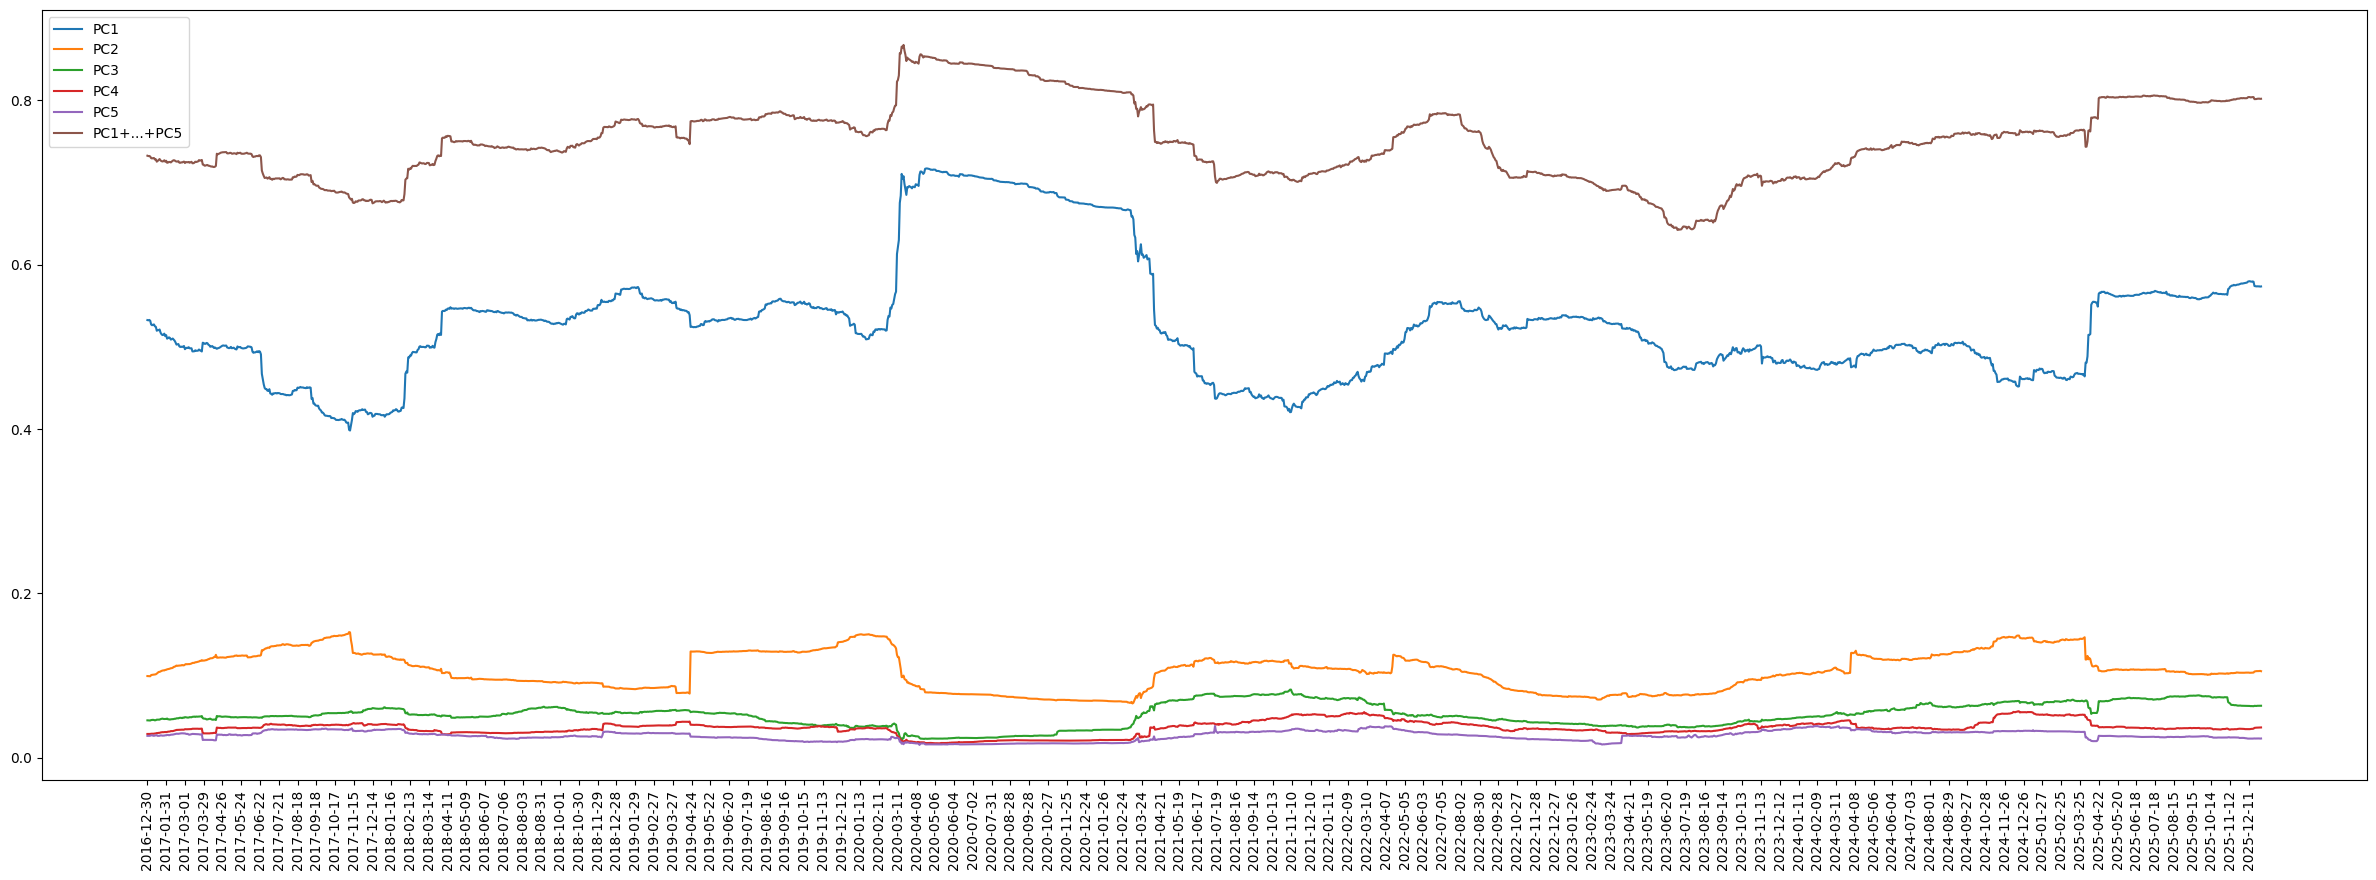

(<matplotlib.legend.Legend at 0x327bd1eb0>, None)

In [83]:
date = returns_df['Date'][window_size:]#[::30]

plt.figure(figsize=(30,10))
for i in range(pca_results.shape[1]):
    plt.plot(date, pca_results[:, i], label=f'PC{i+1}')

plt.plot(date, np.sum(pca_results, axis=1), label=f'PC1+...+PC{pca_results.shape[1]}')
plt.xticks(date[::20], rotation=90)
plt.legend(), plt.show()


In [84]:
returns_df['Date'][returns_df['Date'] == '2019-01-02']


752    2019-01-02
Name: Date, dtype: object